--- Chi-Square Test Results ---
Chi-Square Statistic: 100282577.65
P-value: 0.0000e+00
Degrees of Freedom: 49

Result: Significant difference found. Advertisers use different buzzwords for different genders.


C:\Users\jenny\AppData\Local\Temp\ipykernel_45160\1476905957.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data['Disparity'], y=plot_data.index, palette="RdBu_r")


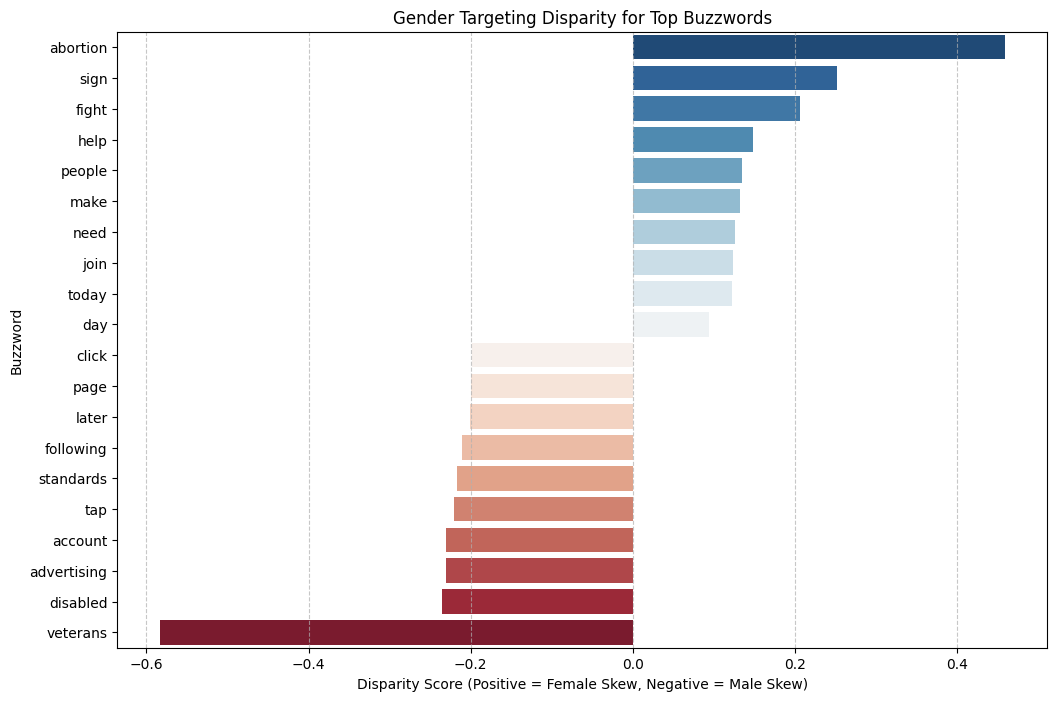

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv('data/ads.csv')
df = df[df['ad_creative_bodies'].notna()].copy()

if 'impressions_mid' not in df.columns:
    df['impressions_mid'] = (df['impressions_lower'] + df['impressions_upper']) / 2

# calc gender totals
demo_cols = [col for col in df.columns if '/' in col]
for gender in ['female', 'male']:
    col_name = f'gender_{gender}_total'
    gender_specific_cols = [c for c in demo_cols if c.lower().endswith(f'/{gender}')]
    df[col_name] = df[gender_specific_cols].sum(axis=1)

# top 50 buzzwords using tfidf
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['ad_creative_bodies'].str.lower())
words = vectorizer.get_feature_names_out()

tfidf_means = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_50_indices = tfidf_means.argsort()[-50:][::-1]
top_50_words = words[top_50_indices]

# contingency table
contingency_data = []
valid_words = []

for word in top_50_words:
    word_idx = np.where(words == word)[0][0]
    word_mask = tfidf_matrix[:, word_idx].toarray().flatten() > 0
    subset = df[word_mask]
    female_hits = (subset['impressions_mid'] * (subset['gender_female_total'] / 100)).sum()
    male_hits = (subset['impressions_mid'] * (subset['gender_male_total'] / 100)).sum()

    if female_hits > 0 or male_hits > 0:
        contingency_data.append([female_hits, male_hits])
        valid_words.append(word)

contingency_table = pd.DataFrame(contingency_data, columns=['Female', 'Male'], index=valid_words)

# chi square test of homogeneity
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
print(f"Degrees of Freedom: {dof}")

if p < 0.05:
    print("\nResult: Significant difference found. Advertisers use different buzzwords for different genders.")
else:
    print("\nResult: No significant difference. Buzzword distribution is homogeneous across genders.")

# visual
# calc which words skew towards one specific gender
contingency_table['Disparity'] = (contingency_table['Female'] - contingency_table['Male']) / (contingency_table['Female'] + contingency_table['Male'])
sorted_disparity = contingency_table.sort_values(by='Disparity', ascending=False)

# plot top 10 words
plot_data = pd.concat([sorted_disparity.head(10), sorted_disparity.tail(10)])

plt.figure(figsize=(12, 8))
sns.barplot(x=plot_data['Disparity'], y=plot_data.index, palette="RdBu_r")
plt.title("Gender Targeting Disparity for Top Buzzwords")
plt.xlabel("Disparity Score (Positive = Female Skew, Negative = Male Skew)")
plt.ylabel("Buzzword")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()